# Figures. Workforce Growth vs. Apprenticeship Pipeline Growth

## Purpose

This notebook creates the apprenticeship dumbbell figures used in the manuscript for:

1. **Healthcare and Social Assistance**
2. **Manufacturing** — including Semiconductor occupations
3. **Construction**

The methodology follows the manuscript narrative.

---

## Measures used

### Employment growth
Employment growth is measured from **2014 to 2025** using Lightcast Maricopa County occupation employment.

\[
\text{Employment Growth} =
\frac{\text{2025 Employment} - \text{2014 Employment}}
{\text{2014 Employment}} \times 100
\]

### Apprenticeship pipeline growth
Apprenticeship growth is measured from **2015 to 2025** using:

**Total Active Apprenticeships**

from the Lightcast Apprenticeships Table.

\[
\text{Active Apprenticeship Growth} =
\frac{\text{2025 Active Apprenticeships} - \text{2015 Active Apprenticeships}}
{\text{2015 Active Apprenticeships}} \times 100
\]

The apprenticeship series begins in 2015 because that is the available baseline in the apprenticeship export.

---

## Data sources

### `Master_CIP_SOC_Matched_Output_3.xlsx`
Used for:
- current 5-star occupation selection;
- sector assignment;
- occupation titles and SOC codes; and
- Semiconductor identification.

Healthcare is stored internally as `Healthcare` in the master file but is displayed in the manuscript as **Healthcare and Social Assistance**.

Semiconductor occupations remain part of the **Manufacturing** figure.

### Lightcast Apprenticeships Table
Used for:
- 2015 Total Active Apprenticeships
- 2025 Total Active Apprenticeships

### Lightcast Maricopa County occupation table
Used for:
- 2014 employment
- 2025 employment

---

## Figure eligibility

An occupation can be shown in the percentage-growth dumbbell only when:

- 2014 employment is greater than zero;
- 2025 employment is available;
- 2015 active apprenticeships are greater than zero; and
- 2025 active apprenticeships are available.

Occupations that do not meet these conditions remain in the QA output.

The figures are descriptive and do not represent the full training pipeline for an occupation.


In [15]:
# ============================================================
# 1. FILE PATHS
# ============================================================

from pathlib import Path
import re
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 150)
pd.set_option("display.max_rows", 120)
pd.set_option("display.width", 240)

# Work computer input folder
BASE = Path(
    r"C:\Users\301533\Documents\Walmart\IPEDS\Files"
)

# Current occupation / sector source
MASTER_FILE = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
    r"\SOC NAICS List\Economic Analysis\Walmart_LMI_Analysis\Current\Python"
    r"\Master_CIP_SOC_Matched_Output_3.xlsx"
)

# Shared Drive output folder
OUTPUT_FOLDER = Path(
    r"G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis"
    r"\SOC NAICS List\Excel Sheets\Arielle Tables"
)

OUTPUT_EXCEL = (
    OUTPUT_FOLDER
    / "Workforce_Growth_vs_Apprenticeship_Pipeline_Growth.xlsx"
)

SECTOR_ORDER = [
    "Healthcare and Social Assistance",
    "Manufacturing",
    "Construction",
]

FIVE_STAR_VALUE = 5

print("Master file:")
print(MASTER_FILE)

print("\nInput folder:")
print(BASE)

print("\nOutput folder:")
print(OUTPUT_FOLDER)


Master file:
G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Economic Analysis\Walmart_LMI_Analysis\Current\Python\Master_CIP_SOC_Matched_Output_3.xlsx

Input folder:
C:\Users\301533\Documents\Walmart\IPEDS\Files

Output folder:
G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables


## 2. Identify the Lightcast files

The notebook finds the source files by their columns rather than relying on a downloaded filename.

The apprenticeship file must contain:
- `SOC`
- `2015 Total Active Apprenticeships`
- `2025 Total Active Apprenticeships`

The employment file must contain:
- `SOC`
- `2014 Jobs`
- `2025 Jobs`


In [16]:
# ============================================================
# 2. FIND LIGHTCAST SOURCE FILES
# ============================================================

candidate_csvs = [
    path
    for path in BASE.glob("*.csv")
    if not path.name.startswith("~$")
]

# ------------------------------------------------------------
# Apprenticeship file
# ------------------------------------------------------------

apprenticeship_candidates = []

for path in candidate_csvs:

    try:
        header = pd.read_csv(
            path,
            nrows=0
        )
    except Exception:
        continue

    column_text = " ".join(
        header.columns.astype(str)
    ).casefold()

    if (
        "soc" in column_text
        and "2015" in column_text
        and "2025" in column_text
        and "total active apprenticeships" in column_text
    ):
        apprenticeship_candidates.append(path)

if not apprenticeship_candidates:
    raise FileNotFoundError(
        "Could not find the Lightcast Apprenticeships Table "
        "with Total Active Apprenticeships columns."
    )

APPRENTICESHIP_FILE = max(
    apprenticeship_candidates,
    key=lambda path: path.stat().st_mtime
)

# ------------------------------------------------------------
# Employment file
# ------------------------------------------------------------

employment_candidates = []

for path in candidate_csvs:

    if path == APPRENTICESHIP_FILE:
        continue

    try:
        header = pd.read_csv(
            path,
            nrows=0
        )
    except Exception:
        continue

    if (
        "SOC" in header.columns
        and "2014 Jobs" in header.columns
        and "2025 Jobs" in header.columns
    ):
        employment_candidates.append(path)

if not employment_candidates:
    raise FileNotFoundError(
        "Could not find a Lightcast occupation file containing "
        "SOC, 2014 Jobs, and 2025 Jobs."
    )

EMPLOYMENT_FILE = max(
    employment_candidates,
    key=lambda path: path.stat().st_mtime
)

print("Apprenticeship source:")
print(APPRENTICESHIP_FILE)

print("\nEmployment source:")
print(EMPLOYMENT_FILE)


Apprenticeship source:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Apprenticeships_Table_ffd7a9dd872079cf.csv

Employment source:
C:\Users\301533\Documents\Walmart\IPEDS\Files\Occupation_Table_All_Occupations_in_Maricopa_County_AZ_4c81adcee7483276.csv


In [17]:
# ============================================================
# 3. HELPERS
# ============================================================

def clean_soc(value):

    if pd.isna(value):
        return np.nan

    match = re.search(
        r"(\d{2})[-\s]?(\d{4})",
        str(value).strip()
    )

    if match:
        return (
            f"{match.group(1)}-"
            f"{match.group(2)}"
        )

    return np.nan


def numeric(series):

    return pd.to_numeric(
        series.astype(str)
        .str.replace(",", "", regex=False)
        .str.replace("%", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.strip(),
        errors="coerce"
    )


def pct_change(end, start):

    end = pd.to_numeric(
        end,
        errors="coerce"
    )

    start = pd.to_numeric(
        start,
        errors="coerce"
    )

    return np.where(
        start > 0,
        (
            (end - start)
            / start
        )
        * 100,
        np.nan
    )


def wrap_label(
    value,
    width=32
):

    return "\n".join(
        textwrap.wrap(
            str(value),
            width=width,
            break_long_words=False
        )
    )


def find_column(
    dataframe,
    year,
    phrase
):

    matches = [
        column
        for column in dataframe.columns
        if (
            str(year) in str(column)
            and phrase.casefold()
            in str(column).casefold()
        )
    ]

    return (
        matches[0]
        if matches
        else None
    )


## 4. Define the current 5-star occupation universe

The current master file uses these internal industry labels:

- `Healthcare`
- `Manufacturing`
- `Construction`

For reporting, `Healthcare` is renamed to **Healthcare and Social Assistance**.

All Semiconductor-flagged occupations remain inside **Manufacturing** for these figures.


In [18]:
# ============================================================
# 4. LOAD CURRENT 5-STAR OCCUPATIONS
# ============================================================

if not MASTER_FILE.exists():
    raise FileNotFoundError(
        f"Master workbook not found:\n{MASTER_FILE}"
    )

master = pd.read_excel(
    MASTER_FILE,
    sheet_name="Master_Matched_Data"
).copy()

required_master_columns = [
    "SOC_Code",
    "Job Title",
    "Industry",
    "Semiconductor Flag",
    "Sum of Occupation Rating by Ed Lvl1",
]

missing_master = [
    column
    for column in required_master_columns
    if column not in master.columns
]

if missing_master:
    raise KeyError(
        f"Master workbook is missing required columns: "
        f"{missing_master}"
    )

master["soc"] = (
    master["SOC_Code"]
    .map(clean_soc)
)

master["stars"] = pd.to_numeric(
    master[
        "Sum of Occupation Rating by Ed Lvl1"
    ],
    errors="coerce"
)

master["industry_clean"] = (
    master["Industry"]
    .fillna("")
    .astype(str)
    .str.strip()
)

master["semiconductor_flag"] = (
    master["Semiconductor Flag"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.casefold()
    .eq("yes")
)

selected = master[
    master["stars"].eq(
        FIVE_STAR_VALUE
    )
    &
    master["soc"].notna()
    &
    master["industry_clean"].isin(
        [
            "Healthcare",
            "Manufacturing",
            "Construction",
        ]
    )
].copy()

selected["sector"] = (
    selected["industry_clean"]
    .replace(
        {
            "Healthcare":
                "Healthcare and Social Assistance"
        }
    )
)

selected = (
    selected[
        [
            "soc",
            "Job Title",
            "sector",
            "semiconductor_flag",
        ]
    ]
    .drop_duplicates(
        "soc"
    )
    .rename(
        columns={
            "Job Title":
                "occupation"
        }
    )
    .reset_index(drop=True)
)

sector_qa = (
    selected
    .groupby(
        "sector"
    )["soc"]
    .nunique()
    .reindex(
        SECTOR_ORDER,
        fill_value=0
    )
)

print("5-star occupations selected:")
print(sector_qa)

missing_sectors = (
    sector_qa[
        sector_qa.eq(0)
    ]
    .index
    .tolist()
)

if missing_sectors:
    raise ValueError(
        "No selected occupations found for: "
        + ", ".join(missing_sectors)
    )

print(
    "\nSemiconductor occupations retained inside Manufacturing:"
)

display(
    selected[
        selected[
            "semiconductor_flag"
        ]
    ]
)


5-star occupations selected:
sector
Healthcare and Social Assistance    25
Manufacturing                       11
Construction                         9
Name: soc, dtype: int64

Semiconductor occupations retained inside Manufacturing:


,soc,occupation,sector,semiconductor_flag
26,17-2061,Computer Hardware Engineers,Manufacturing,True
28,17-2072,"Electronics Engineers, Except Computer",Manufacturing,True
29,17-2112,Industrial Engineers,Manufacturing,True
35,51-9141,Semiconductor Processing Technicians,Manufacturing,True


## 5. Load active apprenticeship counts

The manuscript figures use **Total Active Apprenticeships**, not Incoming Apprenticeships.

This is the measure that reproduces the Healthcare examples described in the manuscript, including:

- Medical Assistants: 21 → 86 active apprentices
- Pharmacy Technicians: 10 → 28
- Dental Assistants: 13 → 11

The code does not hard-code those values; they are pulled from the Lightcast apprenticeship export and shown in the QA table.


In [19]:
# ============================================================
# 5. LOAD ACTIVE APPRENTICESHIPS
# ============================================================

app = pd.read_csv(
    APPRENTICESHIP_FILE,
    low_memory=False
)

if "SOC" not in app.columns:
    raise KeyError(
        "Apprenticeship file does not contain SOC."
    )

app["soc"] = (
    app["SOC"]
    .map(clean_soc)
)

ACTIVE_2015_COL = find_column(
    app,
    2015,
    "Total Active Apprenticeships"
)

ACTIVE_2025_COL = find_column(
    app,
    2025,
    "Total Active Apprenticeships"
)

if ACTIVE_2015_COL is None:
    raise KeyError(
        "Could not find 2015 Total Active Apprenticeships."
    )

if ACTIVE_2025_COL is None:
    raise KeyError(
        "Could not find 2025 Total Active Apprenticeships."
    )

app["active_2015"] = numeric(
    app[
        ACTIVE_2015_COL
    ]
).fillna(0)

app["active_2025"] = numeric(
    app[
        ACTIVE_2025_COL
    ]
).fillna(0)

app_small = (
    app[
        [
            "soc",
            "active_2015",
            "active_2025",
        ]
    ]
    .drop_duplicates(
        "soc"
    )
)

print(
    "Active-apprenticeship columns used:"
)

print(
    "2015:",
    ACTIVE_2015_COL
)

print(
    "2025:",
    ACTIVE_2025_COL
)


Active-apprenticeship columns used:
2015: 2015 Total Active Apprenticeships
2025: 2025 Total Active Apprenticeships


## 6. Load 2014 and 2025 Maricopa County employment

The employment series follows the manuscript x-axis label:

**Growth, 2014–2025 (%)**

Employment is matched to the selected occupations by detailed SOC.


In [20]:
# ============================================================
# 6. LOAD EMPLOYMENT
# ============================================================

jobs = pd.read_csv(
    EMPLOYMENT_FILE,
    low_memory=False
)

required_job_columns = [
    "SOC",
    "2014 Jobs",
    "2025 Jobs",
]

missing_jobs = [
    column
    for column in required_job_columns
    if column not in jobs.columns
]

if missing_jobs:
    raise KeyError(
        f"Employment file is missing: "
        f"{missing_jobs}"
    )

jobs["soc"] = (
    jobs["SOC"]
    .map(clean_soc)
)

jobs["jobs_2014"] = numeric(
    jobs[
        "2014 Jobs"
    ]
)

jobs["jobs_2025"] = numeric(
    jobs[
        "2025 Jobs"
    ]
)

jobs_small = (
    jobs[
        [
            "soc",
            "jobs_2014",
            "jobs_2025",
        ]
    ]
    .drop_duplicates(
        "soc"
    )
)

analysis = (
    selected
    .merge(
        app_small,
        on="soc",
        how="left"
    )
    .merge(
        jobs_small,
        on="soc",
        how="left"
    )
)

analysis["active_2015"] = (
    analysis[
        "active_2015"
    ]
    .fillna(0)
)

analysis["active_2025"] = (
    analysis[
        "active_2025"
    ]
    .fillna(0)
)

analysis[
    "employment_growth_pct"
] = pct_change(
    analysis[
        "jobs_2025"
    ],
    analysis[
        "jobs_2014"
    ]
)

analysis[
    "active_apprenticeship_growth_pct"
] = pct_change(
    analysis[
        "active_2025"
    ],
    analysis[
        "active_2015"
    ]
)

analysis[
    "growth_gap_pp"
] = (
    analysis[
        "active_apprenticeship_growth_pct"
    ]
    -
    analysis[
        "employment_growth_pct"
    ]
)

display(
    analysis[
        [
            "sector",
            "soc",
            "occupation",
            "semiconductor_flag",
            "jobs_2014",
            "jobs_2025",
            "employment_growth_pct",
            "active_2015",
            "active_2025",
            "active_apprenticeship_growth_pct",
            "growth_gap_pp",
        ]
    ]
)


,sector,soc,occupation,semiconductor_flag,jobs_2014,jobs_2025,employment_growth_pct,active_2015,active_2025,active_apprenticeship_growth_pct,growth_gap_pp
0,Healthcare and Social Assistance,35-2012,"Cooks, Institution and Cafeteria",False,4025.604410,4937.418466,22.650364,0,0,NaN,NaN
1,Healthcare and Social Assistance,29-1021,"Dentists, General",False,1506.478986,3046.249121,102.209865,0,0,NaN,NaN
2,Healthcare and Social Assistance,53-2012,Commercial Pilots,False,916.500561,1705.934224,86.135644,0,0,NaN,NaN
3,Healthcare and Social Assistance,21-1094,Community Health Workers,False,592.737999,747.788981,26.158435,0,19,NaN,NaN
4,Healthcare and Social Assistance,29-2032,Diagnostic Medical Sonographers,False,923.370579,1690.020659,83.027345,0,0,NaN,NaN
5,Healthcare and Social Assistance,43-6013,Medical Secretaries and Administrative Assistants,False,9811.498974,13601.673691,38.629925,0,0,NaN,NaN
6,Healthcare and Social Assistance,29-1122,Occupational Therapists,False,979.235954,2218.586160,126.562980,0,0,NaN,NaN
7,Healthcare and Social Assistance,29-1215,Family Medicine Physicians,False,2943.862051,2487.471150,-15.503135,0,0,NaN,NaN
8,Healthcare and Social Assistance,29-1151,Nurse Anesthetists,False,192.980414,398.986373,106.749672,0,0,NaN,NaN
9,Healthcare and Social Assistance,29-2055,Surgical Technologists,False,1446.920394,1772.514125,22.502532,0,0,NaN,NaN


## 7. Manuscript-value QA

Before creating the figures, the notebook checks the Healthcare occupations explicitly discussed in the manuscript.

This is a QA step only. It does not overwrite the source data.

Expected manuscript examples:

| Occupation | Employment Growth | Active Apprenticeship Growth |
|---|---:|---:|
| Medical Assistants | about +115% | about +310% |
| Pharmacy Technicians | about +45% | about +180% |
| Dental Assistants | about +70% | about −15% |

If the values differ materially, review the Lightcast source files before replacing the manuscript figure.


In [21]:
# ============================================================
# 7. MANUSCRIPT QA CHECK
# ============================================================

healthcare_check_names = [
    "Medical Assistants",
    "Pharmacy Technicians",
    "Dental Assistants",
]

healthcare_qa = analysis[
    analysis[
        "occupation"
    ].isin(
        healthcare_check_names
    )
][
    [
        "occupation",
        "jobs_2014",
        "jobs_2025",
        "employment_growth_pct",
        "active_2015",
        "active_2025",
        "active_apprenticeship_growth_pct",
    ]
].copy()

print(
    "Healthcare manuscript QA:"
)

display(
    healthcare_qa
)

expected = pd.DataFrame(
    {
        "occupation": [
            "Medical Assistants",
            "Pharmacy Technicians",
            "Dental Assistants",
        ],
        "expected_employment_growth_pct": [
            115,
            45,
            70,
        ],
        "expected_active_apprenticeship_growth_pct": [
            310,
            180,
            -15,
        ],
    }
)

healthcare_qa_compare = (
    expected
    .merge(
        healthcare_qa,
        on="occupation",
        how="left"
    )
)

healthcare_qa_compare[
    "employment_difference_pp"
] = (
    healthcare_qa_compare[
        "employment_growth_pct"
    ]
    -
    healthcare_qa_compare[
        "expected_employment_growth_pct"
    ]
)

healthcare_qa_compare[
    "apprenticeship_difference_pp"
] = (
    healthcare_qa_compare[
        "active_apprenticeship_growth_pct"
    ]
    -
    healthcare_qa_compare[
        "expected_active_apprenticeship_growth_pct"
    ]
)

display(
    healthcare_qa_compare
)


Healthcare manuscript QA:


,occupation,jobs_2014,jobs_2025,employment_growth_pct,active_2015,active_2025,active_apprenticeship_growth_pct


,occupation,expected_employment_growth_pct,expected_active_apprenticeship_growth_pct,jobs_2014,jobs_2025,employment_growth_pct,active_2015,active_2025,active_apprenticeship_growth_pct,employment_difference_pp,apprenticeship_difference_pp
0,Medical Assistants,115,310,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Pharmacy Technicians,45,180,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Dental Assistants,70,-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. Figure eligibility

Only occupations with a valid starting value for both growth measures are plotted.

This means an occupation with zero active apprentices in 2015 cannot be assigned a percentage apprenticeship growth rate, even if it had apprentices in 2025.

Those occupations remain available in the QA workbook.


In [22]:
# ============================================================
# 8. BUILD PLOTTABLE DATA
# ============================================================

plot_data = analysis[
    analysis[
        "jobs_2014"
    ].gt(0)
    &
    analysis[
        "jobs_2025"
    ].notna()
    &
    analysis[
        "active_2015"
    ].gt(0)
    &
    analysis[
        "active_2025"
    ].notna()
].copy()

plot_data[
    "label"
] = (
    plot_data[
        "occupation"
    ]
    .map(
        wrap_label
    )
)

not_plotted = analysis[
    ~analysis[
        "soc"
    ].isin(
        plot_data[
            "soc"
        ]
    )
].copy()

print(
    "Plottable occupations:"
)

print(
    plot_data
    .groupby(
        "sector"
    )["soc"]
    .nunique()
    .reindex(
        SECTOR_ORDER
    )
)

print(
    "\nNot plotted / QA:"
)

display(
    not_plotted[
        [
            "sector",
            "soc",
            "occupation",
            "jobs_2014",
            "jobs_2025",
            "active_2015",
            "active_2025",
        ]
    ]
)


Plottable occupations:
sector
Healthcare and Social Assistance    NaN
Manufacturing                       4.0
Construction                        5.0
Name: soc, dtype: float64

Not plotted / QA:


,sector,soc,occupation,jobs_2014,jobs_2025,active_2015,active_2025
0,Healthcare and Social Assistance,35-2012,"Cooks, Institution and Cafeteria",4025.604410,4937.418466,0,0
1,Healthcare and Social Assistance,29-1021,"Dentists, General",1506.478986,3046.249121,0,0
2,Healthcare and Social Assistance,53-2012,Commercial Pilots,916.500561,1705.934224,0,0
3,Healthcare and Social Assistance,21-1094,Community Health Workers,592.737999,747.788981,0,19
4,Healthcare and Social Assistance,29-2032,Diagnostic Medical Sonographers,923.370579,1690.020659,0,0
5,Healthcare and Social Assistance,43-6013,Medical Secretaries and Administrative Assistants,9811.498974,13601.673691,0,0
6,Healthcare and Social Assistance,29-1122,Occupational Therapists,979.235954,2218.586160,0,0
7,Healthcare and Social Assistance,29-1215,Family Medicine Physicians,2943.862051,2487.471150,0,0
8,Healthcare and Social Assistance,29-1151,Nurse Anesthetists,192.980414,398.986373,0,0
9,Healthcare and Social Assistance,29-2055,Surgical Technologists,1446.920394,1772.514125,0,0


## 9. Create the manuscript dumbbell figures

Formatting follows the figures already in the draft:

- **orange** = employment growth
- **teal** = active apprenticeships growth
- light-gray connector between the two values
- percentage label above each point
- occupation labels on the left
- legend below the plot
- x-axis labeled **Growth, 2014–2025 (%)**

The apprenticeship series itself begins in 2015; that distinction is documented in the methodology above.


No plottable occupations for Healthcare and Social Assistance.


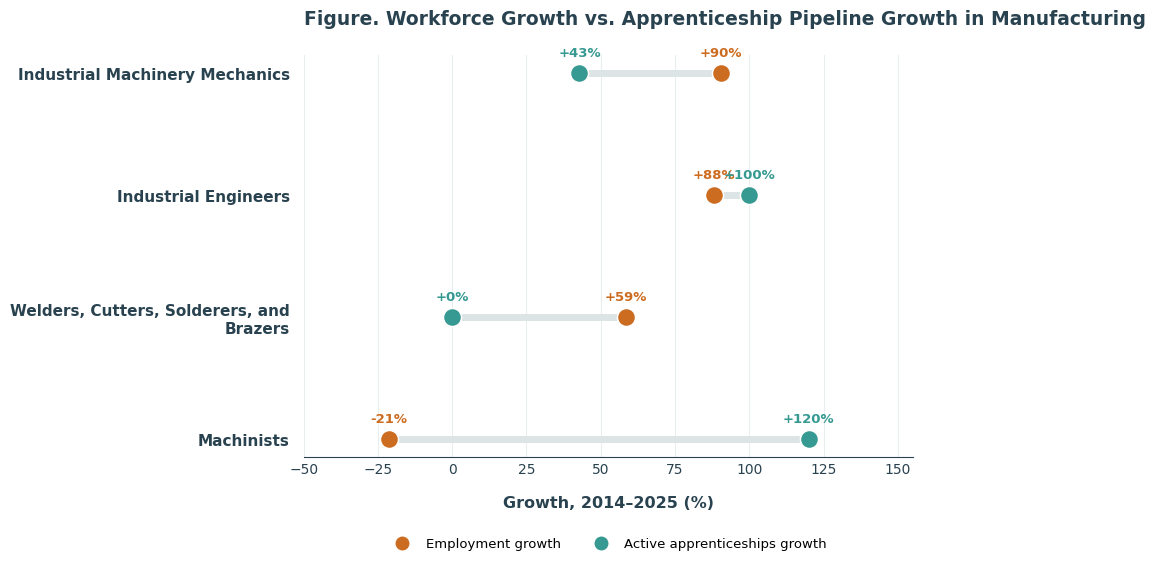

Saved: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_Workforce_Growth_vs_Apprenticeship_Pipeline_Growth_Manufacturing.png


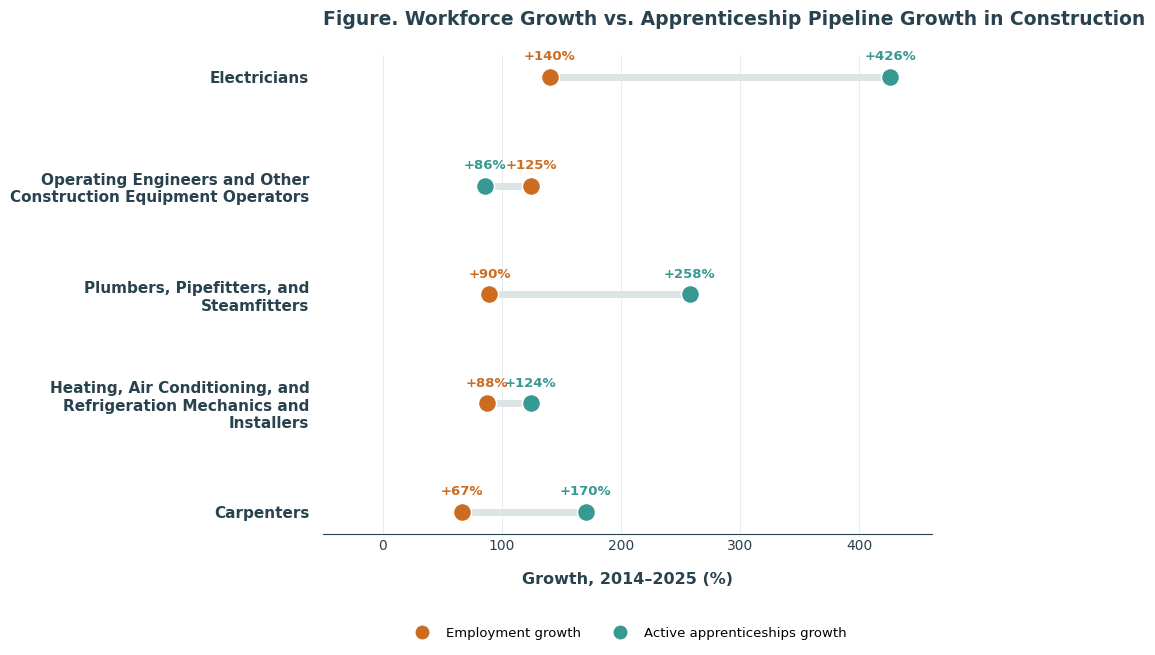

Saved: G:\Shared drives\EO_OPERATIONS\Grants\CFA   Walmart Landscape Analysis\SOC NAICS List\Excel Sheets\Arielle Tables\Figure_Workforce_Growth_vs_Apprenticeship_Pipeline_Growth_Construction.png


In [23]:
# ============================================================
# 9. CREATE DUMBBELL FIGURES
# ============================================================

TEAL = "#369992"
ORANGE = "#CC6C20"
TEXT = "#29424F"
LINE = "#DCE4E6"
GRID = "#E9EDEE"
WHITE = "#FFFFFF"


def make_dumbbell(
    sector_name
):

    chart = (
        plot_data[
            plot_data[
                "sector"
            ].eq(
                sector_name
            )
        ]
        .copy()
    )

    if chart.empty:
        print(
            f"No plottable occupations for {sector_name}."
        )
        return None, None

    # Sort by employment growth, highest at top.
    chart = (
        chart
        .sort_values(
            "employment_growth_pct",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    chart[
        "label"
    ] = (
        chart[
            "occupation"
        ]
        .map(
            wrap_label
        )
    )

    y = np.arange(
        len(chart)
    )

    values = pd.concat(
        [
            chart[
                "employment_growth_pct"
            ],
            chart[
                "active_apprenticeship_growth_pct"
            ],
        ]
    )

    xmin = min(
        -50,
        float(
            values.min()
        )
        - 20
    )

    xmax = max(
        100,
        float(
            values.max()
        )
        + 35
    )

    fig_height = max(
        4.8,
        len(chart)
        * 1.15
        + 1.5
    )

    fig, ax = plt.subplots(
        figsize=(
            10.5,
            fig_height
        )
    )

    fig.patch.set_facecolor(
        WHITE
    )

    ax.set_facecolor(
        WHITE
    )

    for i, row in chart.iterrows():

        employment_growth = row[
            "employment_growth_pct"
        ]

        apprenticeship_growth = row[
            "active_apprenticeship_growth_pct"
        ]

        ax.plot(
            [
                employment_growth,
                apprenticeship_growth,
            ],
            [
                i,
                i,
            ],
            color=LINE,
            linewidth=5,
            zorder=1
        )

        ax.scatter(
            employment_growth,
            i,
            s=170,
            color=ORANGE,
            edgecolor=WHITE,
            linewidth=1.1,
            zorder=3
        )

        ax.scatter(
            apprenticeship_growth,
            i,
            s=170,
            color=TEAL,
            edgecolor=WHITE,
            linewidth=1.1,
            zorder=3
        )

        ax.annotate(
            f"{employment_growth:+.0f}%",
            xy=(
                employment_growth,
                i
            ),
            xytext=(
                0,
                10
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
            color=ORANGE
        )

        ax.annotate(
            f"{apprenticeship_growth:+.0f}%",
            xy=(
                apprenticeship_growth,
                i
            ),
            xytext=(
                0,
                10
            ),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9.5,
            fontweight="bold",
            color=TEAL
        )

    ax.set_yticks(
        y
    )

    ax.set_yticklabels(
        chart[
            "label"
        ],
        fontsize=11,
        fontweight="bold",
        color=TEXT
    )

    ax.invert_yaxis()

    ax.set_xlim(
        xmin,
        xmax
    )

    ax.set_xlabel(
        "Growth, 2014–2025 (%)",
        fontsize=11.5,
        fontweight="bold",
        color=TEXT,
        labelpad=14
    )

    ax.set_title(
        (
            "Figure. Workforce Growth vs. Apprenticeship "
            f"Pipeline Growth in {sector_name}"
        ),
        loc="left",
        fontsize=13.5,
        fontweight="bold",
        color=TEXT,
        pad=22
    )

    ax.grid(
        axis="x",
        color=GRID,
        linewidth=0.8
    )

    ax.grid(
        axis="y",
        visible=False
    )

    ax.set_axisbelow(
        True
    )

    for spine in [
        "top",
        "right",
        "left",
    ]:
        ax.spines[
            spine
        ].set_visible(
            False
        )

    ax.spines[
        "bottom"
    ].set_color(
        TEXT
    )

    ax.tick_params(
        axis="y",
        length=0,
        pad=10
    )

    ax.tick_params(
        axis="x",
        length=0,
        labelsize=10,
        colors=TEXT
    )

    legend_handles = [
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=ORANGE,
            markeredgecolor=ORANGE,
            markersize=9,
            label="Employment growth"
        ),
        plt.Line2D(
            [0],
            [0],
            marker="o",
            linestyle="None",
            markerfacecolor=TEAL,
            markeredgecolor=TEAL,
            markersize=9,
            label="Active apprenticeships growth"
        ),
    ]

    ax.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(
            0.5,
            -0.17
        ),
        ncol=2,
        frameon=False,
        fontsize=9.5
    )

    plt.subplots_adjust(
        left=0.38,
        right=0.96,
        top=0.88,
        bottom=0.22
    )

    safe_name = (
        sector_name
        .replace(
            "Healthcare and Social Assistance",
            "Healthcare_and_Social_Assistance"
        )
        .replace(
            " ",
            "_"
        )
    )

    output_png = (
        OUTPUT_FOLDER
        / (
            "Figure_Workforce_Growth_vs_Apprenticeship_"
            f"Pipeline_Growth_{safe_name}.png"
        )
    )

    plt.savefig(
        output_png,
        dpi=300,
        bbox_inches="tight",
        facecolor=WHITE
    )

    plt.show()

    print(
        "Saved:",
        output_png
    )

    return (
        chart,
        output_png
    )


FIGURE_DATA = {}
FIGURE_FILES = {}

for sector in SECTOR_ORDER:

    chart, output_png = make_dumbbell(
        sector
    )

    if chart is not None:

        FIGURE_DATA[
            sector
        ] = chart

        FIGURE_FILES[
            sector
        ] = output_png
